# Analyse de série temporelles 

### **Chargement des données**

In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose



df = pd.read_csv("data/raw_AAPL.csv", header=[0, 1], index_col=0, parse_dates=True, skiprows=[2])
df.columns = [col[0] for col in df.columns]

print(df.head())
print(df.dtypes)

                Close       High        Low       Open     Volume
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


### **Visualisation de la série brute**


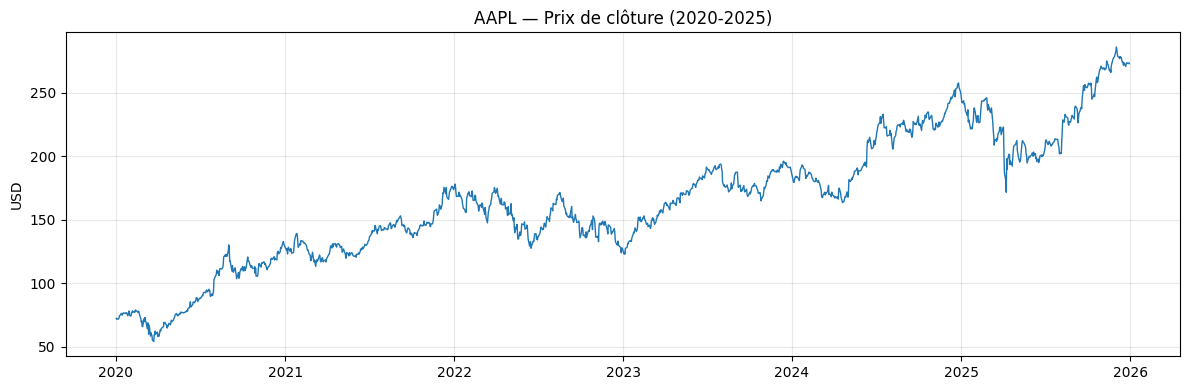

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["Close"], linewidth=1, color="#1f77b4")
ax.set_title("AAPL — Prix de clôture (2020-2025)")
ax.set_ylabel("USD")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Décomposition de la série**

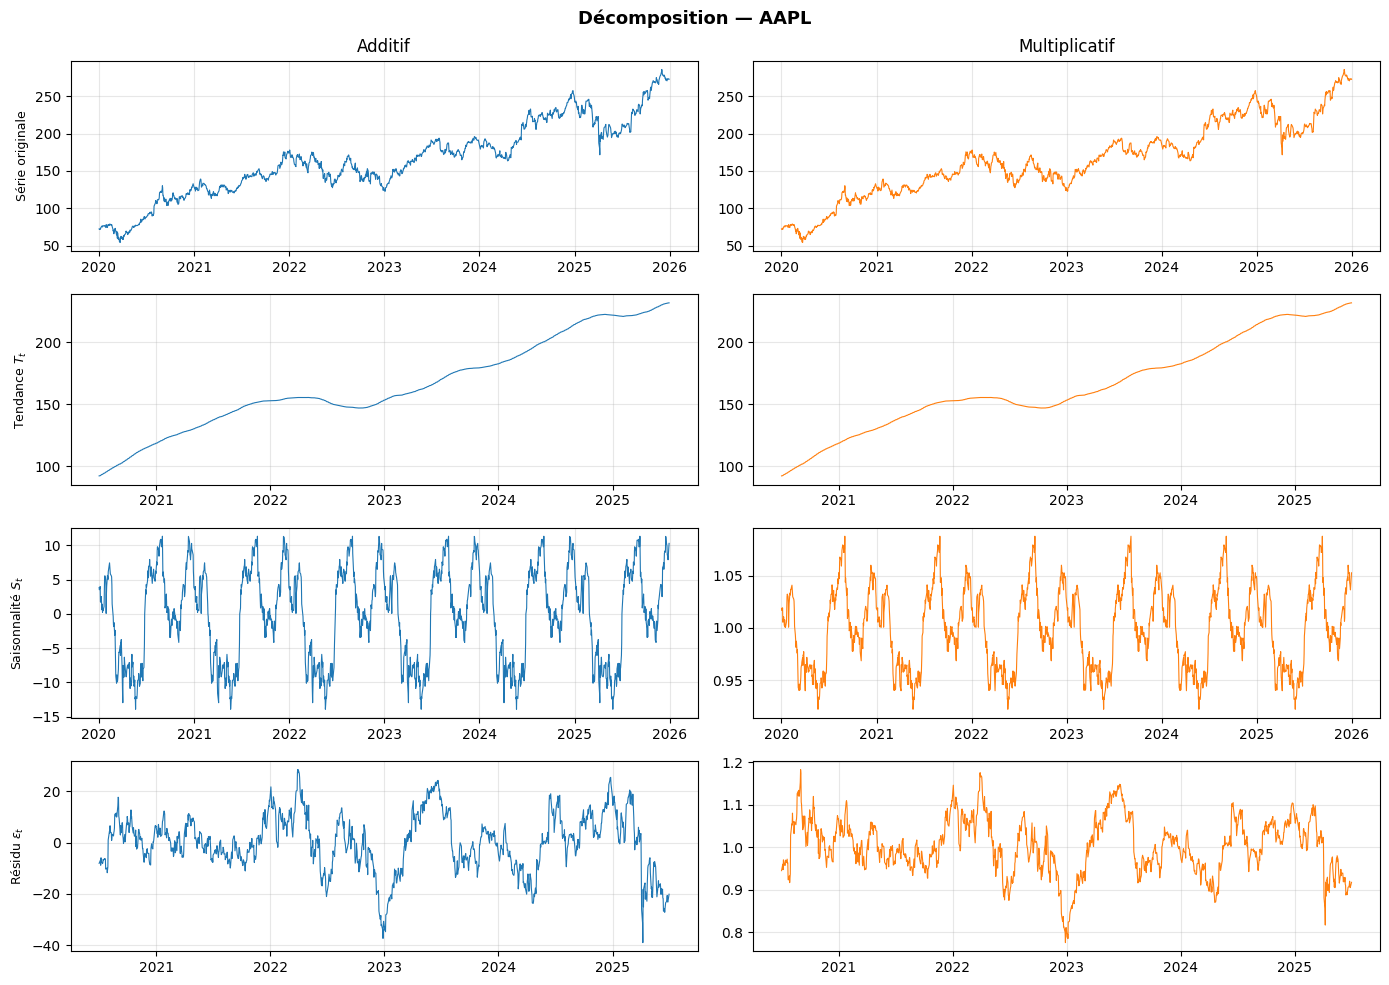

In [17]:
# décomposition additive
decomp_add = seasonal_decompose(df["Close"], model="additive", period=252)

# décomposition multiplicative  
decomp_mul = seasonal_decompose(df["Close"], model="multiplicative", period=252)

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle("Décomposition — AAPL", fontsize=13, fontweight="bold")

composantes = ["observed", "trend", "seasonal", "resid"]
labels = ["Série originale", "Tendance $T_t$", "Saisonnalité $S_t$", "Résidu $\\varepsilon_t$"]

for i, (comp, label) in enumerate(zip(composantes, labels)):
    # additif
    axes[i][0].plot(getattr(decomp_add, comp), linewidth=0.8, color="#1f77b4")
    axes[i][0].set_ylabel(label, fontsize=9)
    if i == 0:
        axes[i][0].set_title("Additif")
    axes[i][0].grid(True, alpha=0.3)

    # multiplicatif
    axes[i][1].plot(getattr(decomp_mul, comp), linewidth=0.8, color="#ff7f0e")
    if i == 0:
        axes[i][1].set_title("Multiplicatif")
    axes[i][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visuellement on constate que le modèle est additif, car l'amplitude de la saisonnalité n'augmente pas on même temps que la tendance. Elle est d'ailleurs constante

### **Détection de la saisonnalité/ tendance**

In [23]:
df_monthly = df["Close"].resample("ME").mean()
print(df_monthly.head(12))
print(f"\nNombre de mois : {len(df_monthly)}")

2020-01-31     75.188593
2020-02-29     75.172660
2020-03-31     63.413295
2020-04-30     65.815563
2020-05-31     75.054749
2020-06-30     83.781963
2020-07-31     92.615162
2020-08-31    113.845681
2020-09-30    111.771327
2020-10-31    113.021755
2020-11-30    113.580267
2020-12-31    123.795344
Freq: ME, Name: Close, dtype: float64

Nombre de mois : 72


In [24]:
df_anova = df_monthly.to_frame()
df_anova.index = pd.to_datetime(df_anova.index)
df_anova["annee"] = df_anova.index.year
df_anova["mois"] = df_anova.index.month

tableau = df_anova.pivot(index="annee", columns="mois", values="Close")
tableau.columns = [f"M{m:02d}" for m in tableau.columns]

print(tableau)

              M01         M02         M03         M04         M05         M06  \
annee                                                                           
2020    75.188593   75.172660   63.413295   65.815563   75.054749   83.781963   
2021   129.383955  128.069829  118.702115  128.385139  123.653941  126.794144   
2022   166.215897  166.362458  161.968607  163.448636  145.599670  137.173723   
2023   133.635999  148.728725  152.751851  162.688902  170.297702  181.902983   
2024   185.794163  183.037861  171.138992  168.074919  184.779421  204.680157   
2025   233.312483  237.412227  221.736434  200.310776  203.240835  200.048235   

              M07         M08         M09         M10         M11         M12  
annee                                                                          
2020    92.615162  113.845681  111.771327  113.021755  113.580267  123.795344  
2021   141.605369  144.747201  144.911724  142.232109  150.904208  169.827906  
2022   146.860302  163.940531  

In [25]:
# moyennes marginales
moy_mois = tableau.mean(axis=0)   # moyenne de chaque mois sur toutes les années
moy_annee = tableau.mean(axis=1)  # moyenne de chaque année sur tous les mois
moy_generale = tableau.values.mean()  # moyenne générale

print("Moyennes par mois :\n", moy_mois)
print("\nMoyennes par année :\n", moy_annee)
print(f"\nMoyenne générale : {moy_generale:.4f}")



Moyennes par mois :
 M01    153.921848
M02    156.463960
M03    148.285216
M04    148.120656
M05    150.437720
M06    155.730201
M07    167.420304
M08    174.283194
M09    174.382739
M10    176.124325
M11    181.621372
M12    190.977061
dtype: float64

Moyennes par année :
 annee
2020     92.254697
2021    137.434803
2022    151.967084
2023    170.219309
2024    205.485551
2025    231.522853
dtype: float64

Moyenne générale : 164.8140


In [26]:
n_annees = tableau.shape[0]   # 6
n_mois = tableau.shape[1]     # 12
N = n_annees * n_mois         # 72

# somme des carrés totale
SCT = ((tableau.values - moy_generale) ** 2).sum()

# somme des carrés années
SCA = n_mois * ((moy_annee.values - moy_generale) ** 2).sum()

# somme des carrés mois (saisonnalité)
SCM = n_annees * ((moy_mois.values - moy_generale) ** 2).sum()

# somme des carrés résiduelle
SCR = SCT - SCA - SCM

print(f"SCT = {SCT:.4f}")
print(f"SCA = {SCA:.4f}")
print(f"SCM = {SCM:.4f}")
print(f"SCR = {SCR:.4f}")

SCT = 175453.8535
SCA = 147755.7570
SCM = 13874.1576
SCR = 13823.9388


In [27]:
# degrés de liberté
ddl_annee = n_annees - 1        # 5
ddl_mois = n_mois - 1           # 11
ddl_residuel = (n_annees - 1) * (n_mois - 1)  # 55

# variances
VA = SCA / ddl_annee
VM = SCM / ddl_mois
VR = SCR / ddl_residuel

# fisher
F_annee = VA / VR
F_mois = VM / VR

print(f"Variance année   : {VA:.4f}")
print(f"Variance mois    : {VM:.4f}")
print(f"Variance résidu  : {VR:.4f}")
print(f"\nF_année  = {F_annee:.4f}")
print(f"F_mois   = {F_mois:.4f}")
print(f"\nValeur critique Fisher (α=5%) :")
print(f"  F_année  : ddl ({ddl_annee}, {ddl_residuel})")
print(f"  F_mois   : ddl ({ddl_mois}, {ddl_residuel})")

Variance année   : 29551.1514
Variance mois    : 1261.2871
Variance résidu  : 251.3443

F_année  = 117.5724
F_mois   = 5.0182

Valeur critique Fisher (α=5%) :
  F_année  : ddl (5, 55)
  F_mois   : ddl (11, 55)


## Conclusion

Le test de Fisher confirme à 5% :
- Une **tendance** significative (F = 117.57 >> 2.39)
- Une **saisonnalité** mensuelle significative (F = 5.02 > 2.00)

Le schéma **additif** est retenu (amplitude saisonnière constante, confirmée visuellement).
On peut procéder au lissage Holt-Winters.

### **Identification du modèle** 

In [28]:
# écart type de chaque année (sur les 12 mois)
V_i = tableau.std(axis=1)

# moyenne de chaque année (déjà calculée)
X_i = moy_annee

print("Écarts types par année :\n", V_i)
print("\nMoyennes par année :\n", X_i)

# corrélation
corr = np.corrcoef(X_i.values, V_i.values)[0, 1]
print(f"\nCorrélation(Xi, Vi) = {corr:.4f}")

# régression Vi = a * Xi + b
a_hat = np.cov(X_i.values, V_i.values)[0, 1] / np.var(X_i.values)
b_hat = V_i.mean() - a_hat * X_i.mean()

print(f"\nâ = {a_hat:.4f}")
print(f"b̂ = {b_hat:.4f}")

Écarts types par année :
 annee
2020    21.762332
2021    14.362153
2022    11.675937
2023    17.749420
2024    26.073977
2025    26.587902
dtype: float64

Moyennes par année :
 annee
2020     92.254697
2021    137.434803
2022    151.967084
2023    170.219309
2024    205.485551
2025    231.522853
dtype: float64

Corrélation(Xi, Vi) = 0.5295

â = 0.0787
b̂ = 6.7272


### Conclusion

On teste H0 : "le modèle est additif" contre H1 : "le modèle est multiplicatif".

On calcule l'écart type de chaque année Vi et on l'analyse par rapport 
à la moyenne annuelle Xi :

| Année | Xi     | Vi    | √Xi  |
|-------|--------|-------|------|
| 2020  | 92.25  | 21.76 | 9.59 |
| 2021  | 137.43 | 14.36 | 11.70|
| 2022  | 151.97 | 11.68 | 12.33|
| 2023  | 170.22 | 17.75 | 13.04|
| 2024  | 205.49 | 26.07 | 14.32|
| 2025  | 231.52 | 26.59 | 15.23|

La corrélation entre Vi et Xi vaut 0.53, ce qui pourrait suggérer 
un modèle multiplicatif. Cependant :

- Vi ne croît pas linéairement avec Xi (baisse de 2020 à 2022, 
  puis remonte) → on ne retient pas H1 multiplicatif
- Vi ne croît pas non plus en racine carrée de Xi 
  → on ne retient pas le pseudo-additif
- Visuellement, l'amplitude saisonnière reste constante 
  quelle que soit la tendance

**Conclusion : on retient H0 — le modèle est additif.**

$$Y_t = T_t + S_t + \varepsilon_t$$

### **Lissage de hotlwinter**

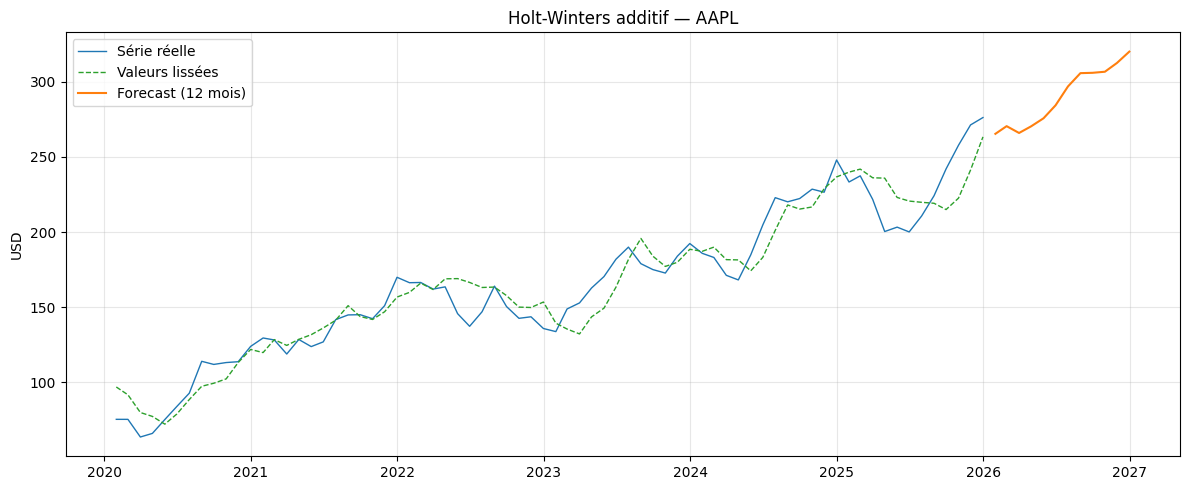


Alpha (niveau)     : 0.4000
Beta  (tendance)   : 0.1000
Gamma (saisonnalité): 0.1000


In [30]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# on travaille sur la série mensuelle
model = ExponentialSmoothing(
    df_monthly,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(
    smoothing_level=0.4,
    smoothing_trend=0.1,
    smoothing_seasonal=0.1,
    optimized=False
)

# forecast 12 mois
forecast = model.forecast(12)

# visualisation
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_monthly.index, df_monthly, label="Série réelle", linewidth=1, color="#1f77b4")
ax.plot(model.fittedvalues.index, model.fittedvalues, label="Valeurs lissées", linewidth=1, color="#2ca02c", linestyle="--")
ax.plot(forecast.index, forecast, label="Forecast (12 mois)", linewidth=1.5, color="#ff7f0e")

ax.set_title("Holt-Winters additif — AAPL")
ax.set_ylabel("USD")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAlpha (niveau)     : {model.params['smoothing_level']:.4f}")
print(f"Beta  (tendance)   : {model.params['smoothing_trend']:.4f}")
print(f"Gamma (saisonnalité): {model.params['smoothing_seasonal']:.4f}")

### **Evaluation du modèle**

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(df_monthly, model.fittedvalues)
rmse = np.sqrt(mean_squared_error(df_monthly, model.fittedvalues))

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 10.9122
RMSE : 13.9091


| Métrique | Valeur |
|---|---|
| MAE | 10.91 $ |
| RMSE | 13.91 $ |

Le modèle se trompe en moyenne de 10.91$ par mois, soit environ 6.6% 
du prix moyen (164$). Ce résultat est acceptable pour un lissage 
Holt-Winters additif avec des paramètres fixés (α=0.4, β=0.1, γ=0.1).